In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

RAW   = Path('../data/raw')
SYN   = Path('../data/synthetic')
PROC  = Path('../data/processed')
PROC.mkdir(exist_ok=True)

print("Imports OK")

Imports OK


In [5]:
# Find the xls file — name varies by extraction
uci_files = list(RAW.glob('*.xls*'))
print("Found:", uci_files)

uci_path = uci_files[0]
df_uci = pd.read_excel(uci_path, header=1)   # header=1 skips the merged title row

print(f"Shape: {df_uci.shape}")
df_uci.head(3)

Found: [WindowsPath('../data/raw/default of credit card clients.xls')]
Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


In [6]:
df_uci.columns = [c.strip().lower().replace(' ', '_') for c in df_uci.columns]

# Rename the target for clarity
df_uci.rename(columns={'default_payment_next_month': 'default_flag'}, inplace=True)

# Drop the ID column — not a feature
df_uci.drop(columns=['id'], inplace=True, errors='ignore')

print(df_uci.columns.tolist())
print(f"\nTarget distribution:\n{df_uci['default_flag'].value_counts()}")
print(f"\nDefault rate: {df_uci['default_flag'].mean():.2%}")

['limit_bal', 'sex', 'education', 'marriage', 'age', 'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6', 'default_flag']

Target distribution:
default_flag
0    23364
1     6636
Name: count, dtype: int64

Default rate: 22.12%


In [7]:
# Missing values
missing = df_uci.isnull().sum()
print("Missing values:\n", missing[missing > 0] if missing.any() else "None — clean dataset")

# Data types
print("\nDtypes:\n", df_uci.dtypes.value_counts())

# Basic stats
df_uci.describe().round(2)

Missing values:
 None — clean dataset

Dtypes:
 int64    24
Name: count, dtype: int64


,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,bill_amt1,bill_amt2,bill_amt3,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default_flag
count,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000
mean,167484.3200,1.6000,1.8500,1.5500,35.4900,-0.0200,-0.1300,-0.1700,-0.2200,-0.2700,-0.2900,51223.3300,49179.0800,47013.1500,43262.9500,40311.4000,38871.7600,5663.5800,5921.1600,5225.6800,4826.0800,4799.3900,5215.5000,0.2200
std,129747.6600,0.4900,0.7900,0.5200,9.2200,1.1200,1.2000,1.2000,1.1700,1.1300,1.1500,73635.8600,71173.7700,69349.3900,64332.8600,60797.1600,59554.1100,16563.2800,23040.8700,17606.9600,15666.1600,15278.3100,17777.4700,0.4200
min,10000.0000,1.0000,0.0000,0.0000,21.0000,-2.0000,-2.0000,-2.0000,-2.0000,-2.0000,-2.0000,-165580.0000,-69777.0000,-157264.0000,-170000.0000,-81334.0000,-339603.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,50000.0000,1.0000,1.0000,1.0000,28.0000,-1.0000,-1.0000,-1.0000,-1.0000,-1.0000,-1.0000,3558.7500,2984.7500,2666.2500,2326.7500,1763.0000,1256.0000,1000.0000,833.0000,390.0000,296.0000,252.5000,117.7500,0.0000
50%,140000.0000,2.0000,2.0000,2.0000,34.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,22381.5000,21200.0000,20088.5000,19052.0000,18104.5000,17071.0000,2100.0000,2009.0000,1800.0000,1500.0000,1500.0000,1500.0000,0.0000
75%,240000.0000,2.0000,2.0000,2.0000,41.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,67091.0000,64006.2500,60164.7500,54506.0000,50190.5000,49198.2500,5006.0000,5000.0000,4505.0000,4013.2500,4031.5000,4000.0000,0.0000
max,1000000.0000,2.0000,6.0000,3.0000,79.0000,8.0000,8.0000,8.0000,8.0000,8.0000,8.0000,964511.0000,983931.0000,1664089.0000,891586.0000,927171.0000,961664.0000,873552.0000,1684259.0000,896040.0000,621000.0000,426529.0000,528666.0000,1.0000


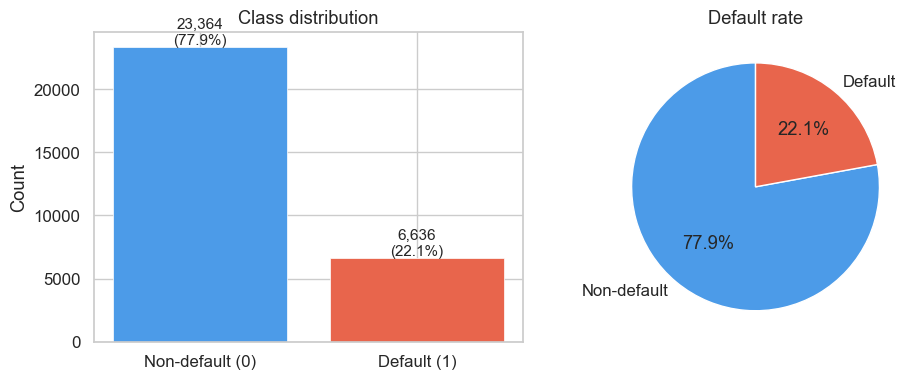

Imbalance ratio: 3.5:1


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
counts = df_uci['default_flag'].value_counts()
axes[0].bar(['Non-default (0)', 'Default (1)'], counts.values,
            color=['#4C9BE8', '#E8654C'], edgecolor='white', linewidth=0.5)
axes[0].set_title('Class distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df_uci):.1%})',
                 ha='center', fontsize=11)

# Pie chart
axes[1].pie(counts.values, labels=['Non-default', 'Default'],
            colors=['#4C9BE8', '#E8654C'], autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Default rate')

plt.tight_layout()
plt.savefig('../data/processed/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Imbalance ratio: {counts[0]/counts[1]:.1f}:1")

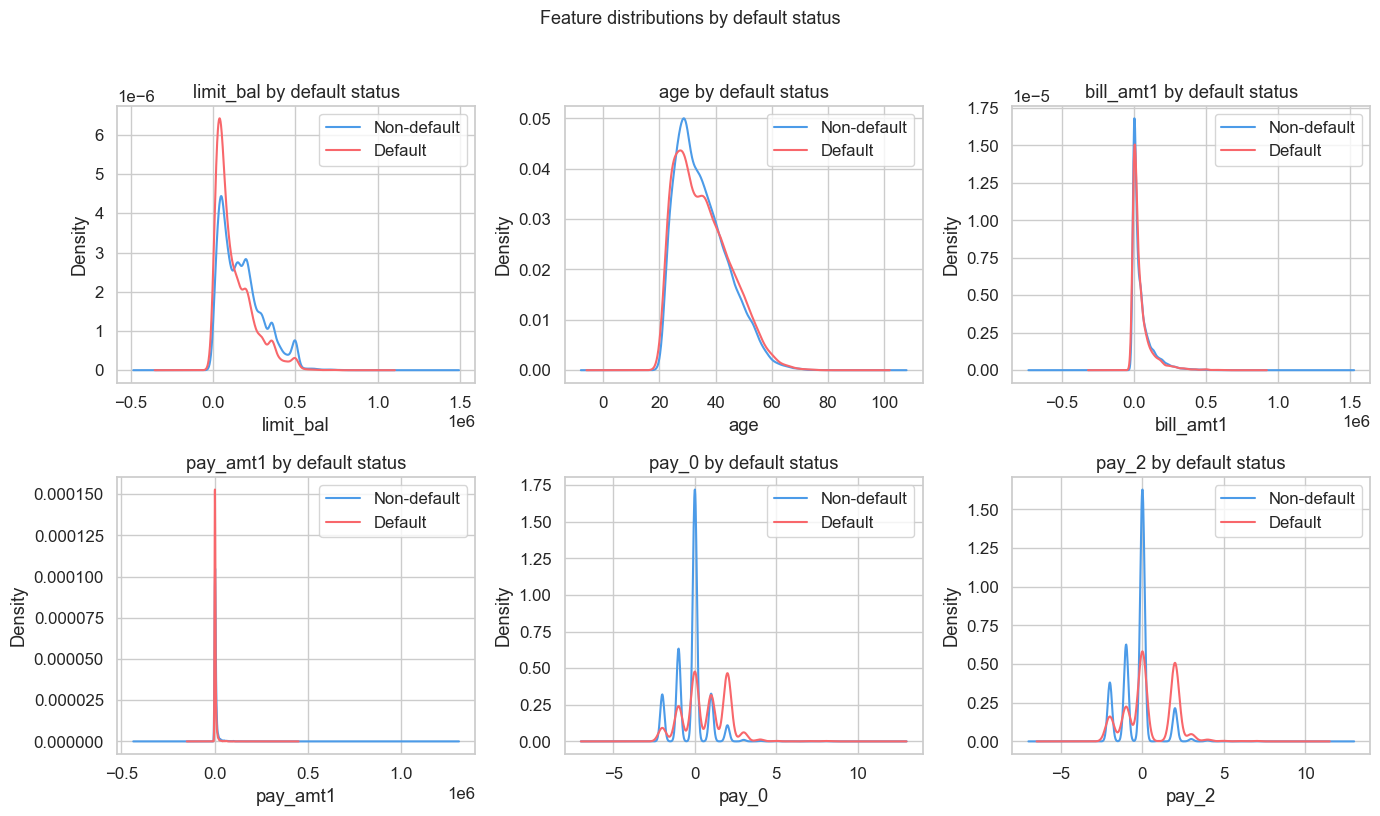

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

features_to_plot = ['limit_bal', 'age', 'bill_amt1', 'pay_amt1', 'pay_0', 'pay_2']

for ax, col in zip(axes, features_to_plot):
    df_uci[df_uci['default_flag'] == 0][col].plot(
        kind='kde',
        ax=ax,
        color='#4C9BE8',
        linewidth=1.5,
        label='Non-default'
    )

    df_uci[df_uci['default_flag'] == 1][col].plot(
        kind='kde',
        ax=ax,
        color='#F8676B',
        linewidth=1.5,
        label='Default'
    )

    ax.set_title(f'{col} by default status')
    ax.set_xlabel(col)
    ax.legend()

plt.suptitle('Feature distributions by default status', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

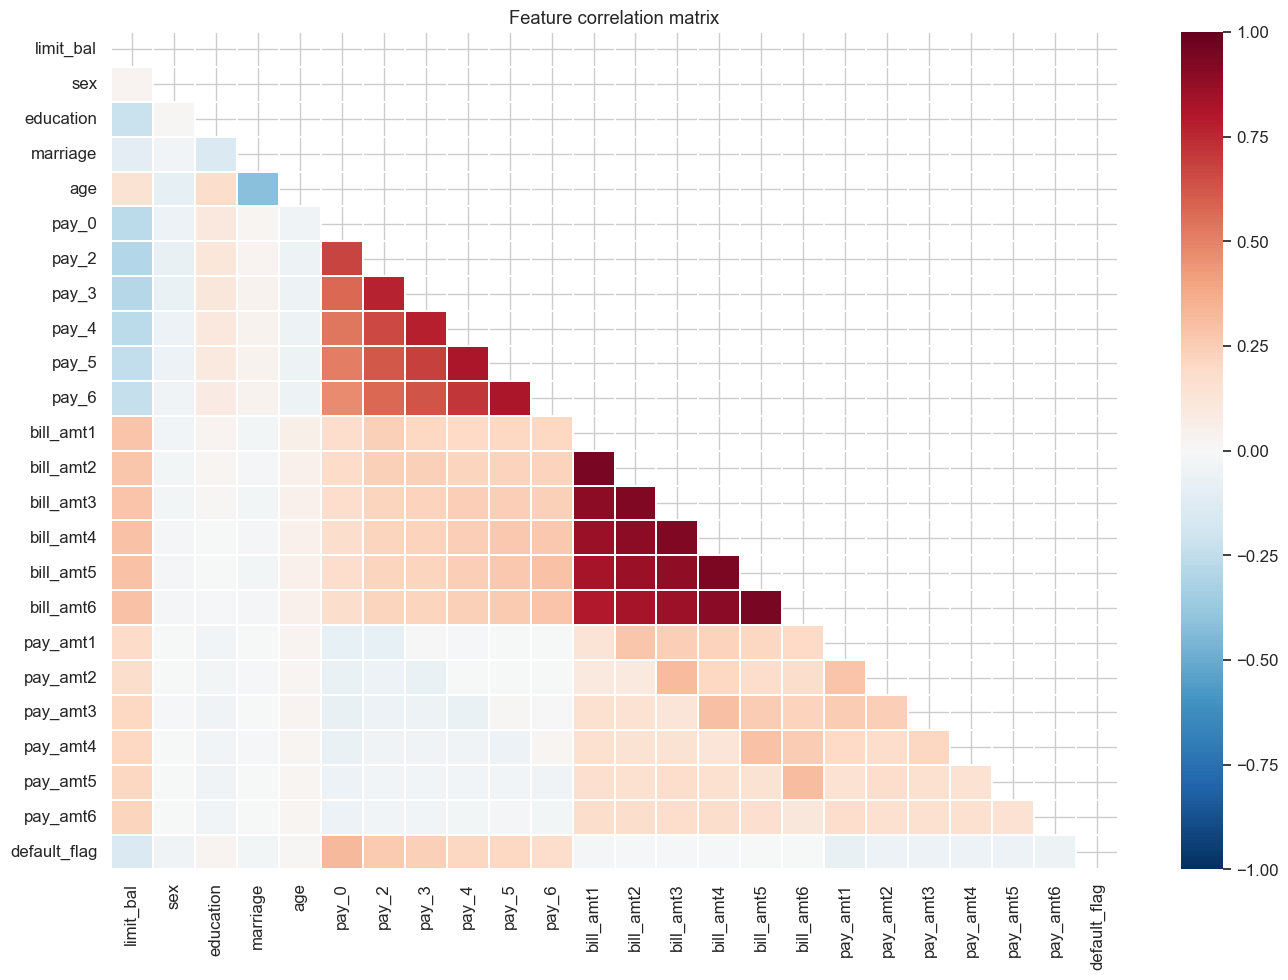

Top correlations with default_flag:
default_flag   1.0000
pay_0          0.3248
pay_2          0.2636
pay_3          0.2353
pay_4          0.2166
pay_5          0.2041
pay_6          0.1869
limit_bal      0.1535
pay_amt1       0.0729
pay_amt2       0.0586
Name: default_flag, dtype: float64


In [12]:
corr = df_uci.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r',
            center=0, linewidths=0.3, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.show()

# Print top correlations with target
print("Top correlations with default_flag:")
print(corr['default_flag'].abs().sort_values(ascending=False).head(10))

In [14]:
df_upi = pd.read_csv(SYN / 'upi_features_raw.csv')

print(f"UPI features shape: {df_upi.shape}")
print(df_upi.head(3))

# Merge: UPI features + UCI labels (already has default_flag nudged in)
import sys
sys.path.insert(0, '..')
from src.features.synthetic_data import merge_with_labels

df_upi_labeled = merge_with_labels(df_upi, df_uci['default_flag'])

print(f"\nMerged shape: {df_upi_labeled.shape}")
print(f"Default rate in merged: {df_upi_labeled['default_flag'].mean():.2%}")

UPI features shape: (30000, 15)
   monthly_txn_count  avg_txn_amount  txn_amount_std  txn_regularity_score  \
0                 51        457.8410        245.1883                0.6155   
1                 53       2204.6034        431.7803                0.5545   
2                 50       4991.2952        176.0589                0.9102   

   salary_credit_regular  recharge_consistency  utility_payment_ratio  \
0                      1                0.6656                 0.8331   
1                      1                0.5945                 0.5981   
2                      0                0.8649                 0.7870   

   late_payment_flag  emi_to_income_proxy  merchant_diversity  \
0                  0               0.2742                  38   
1                  0               0.3414                   3   
2                  0               0.1553                  28   

   weekend_spend_ratio  essential_spend_ratio  p2p_to_merchant_ratio  \
0               0.1589       

In [15]:
# Reset indices so concat aligns correctly
df_uci_features = df_uci.drop(columns=['default_flag']).reset_index(drop=True)
df_upi_features = df_upi_labeled.drop(columns=['default_flag']).reset_index(drop=True)
labels          = df_uci['default_flag'].reset_index(drop=True)

# Combine both feature sets side by side
df_combined = pd.concat([df_uci_features, df_upi_features], axis=1)
df_combined['default_flag'] = labels

print(f"Combined shape: {df_combined.shape}")
print(f"Columns: {df_combined.columns.tolist()}")
df_combined.head(3)

Combined shape: (30000, 39)
Columns: ['limit_bal', 'sex', 'education', 'marriage', 'age', 'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6', 'monthly_txn_count', 'avg_txn_amount', 'txn_amount_std', 'txn_regularity_score', 'salary_credit_regular', 'recharge_consistency', 'utility_payment_ratio', 'late_payment_flag', 'emi_to_income_proxy', 'merchant_diversity', 'weekend_spend_ratio', 'essential_spend_ratio', 'p2p_to_merchant_ratio', 'months_active', 'balance_volatility', 'default_flag']


,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,bill_amt1,bill_amt2,bill_amt3,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,monthly_txn_count,avg_txn_amount,txn_amount_std,txn_regularity_score,salary_credit_regular,recharge_consistency,utility_payment_ratio,late_payment_flag,emi_to_income_proxy,merchant_diversity,weekend_spend_ratio,essential_spend_ratio,p2p_to_merchant_ratio,months_active,balance_volatility,default_flag
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,51,457.8410,245.1883,0.5122,1,0.6656,0.4522,0,0.2742,38,0.1589,0.7789,0.5198,13,0.3219,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,53,2204.6034,431.7803,0.4057,0,0.5945,0.4461,1,0.3414,3,0.4129,0.8633,0.2970,13,0.3234,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,50,4991.2952,176.0589,0.9102,0,0.8649,0.7870,0,0.1553,28,0.2350,0.5075,0.3210,18,0.1504,0


In [16]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # --- UCI-derived features ---

    # Average bill across 6 months
    bill_cols = [f'bill_amt{i}' for i in range(1, 7)]
    pay_cols  = [f'pay_amt{i}'  for i in range(1, 7)]

    df['avg_bill_6m']       = df[bill_cols].mean(axis=1)
    df['avg_payment_6m']    = df[pay_cols].mean(axis=1)
    df['bill_trend']        = df['bill_amt1'] - df['bill_amt6']   # +ve = bills growing
    df['payment_trend']     = df['pay_amt1'] - df['pay_amt6']     # +ve = payments growing

    # Payment ratio — how much of the bill is being paid
    total_bill = df[bill_cols].sum(axis=1).replace(0, np.nan)
    total_paid = df[pay_cols].sum(axis=1)
    df['payment_ratio'] = (total_paid / total_bill).clip(0, 5).fillna(0)

    # Repayment consistency — how often was pay status <= 0 (on time)
    pay_status_cols = [f'pay_{i}' for i in [0,2,3,4,5,6]]
    df['repayment_consistency'] = (df[pay_status_cols] <= 0).mean(axis=1)

    # Max consecutive delay
    df['max_delay_status'] = df[pay_status_cols].max(axis=1)

    # Credit utilisation
    df['credit_utilisation'] = (df['avg_bill_6m'] / df['limit_bal'].replace(0, np.nan)).clip(0, 2).fillna(0)

    # Age bands
    df['age_band'] = pd.cut(df['age'],
                            bins=[0, 25, 35, 45, 60, 100],
                            labels=[0, 1, 2, 3, 4]).astype(float)

    # --- UPI-derived features ---

    # RFM-style spend momentum
    df['spend_momentum'] = df['avg_txn_amount'] * df['monthly_txn_count']

    # Payment discipline composite score
    df['payment_discipline'] = (
        df['utility_payment_ratio']  * 0.40 +
        df['recharge_consistency']   * 0.30 +
        (1 - df['late_payment_flag'])* 0.30
    )

    # Financial stability index
    df['financial_stability'] = (
        df['salary_credit_regular']  * 0.50 +
        df['txn_regularity_score']   * 0.30 +
        df['payment_discipline']     * 0.20
    )

    # Spend volatility
    df['spend_volatility'] = (
        df['txn_amount_std'] / df['avg_txn_amount'].replace(0, np.nan)
    ).clip(0, 10).fillna(0)

    # Cross-feature: credit utilisation x payment discipline
    df['util_x_discipline'] = df['credit_utilisation'] * df['payment_discipline']

    # Cross-feature: repayment consistency x financial stability
    df['repayment_x_stability'] = df['repayment_consistency'] * df['financial_stability']

    return df


df_engineered = engineer_features(df_combined)

new_cols = [c for c in df_engineered.columns if c not in df_combined.columns]
print(f"Added {len(new_cols)} engineered features:")
for c in new_cols:
    print(f"  {c}")

Added 15 engineered features:
  avg_bill_6m
  avg_payment_6m
  bill_trend
  payment_trend
  payment_ratio
  repayment_consistency
  max_delay_status
  credit_utilisation
  age_band
  spend_momentum
  payment_discipline
  financial_stability
  spend_volatility
  util_x_discipline
  repayment_x_stability


In [17]:
# Save the full engineered dataset
df_engineered.to_csv(PROC / 'features_engineered.csv', index=False)

# Also save the feature names list (useful later for SHAP)
feature_cols = [c for c in df_engineered.columns if c != 'default_flag']
pd.Series(feature_cols).to_csv(PROC / 'feature_names.csv', index=False, header=False)

print(f"Saved {df_engineered.shape[0]:,} rows × {len(feature_cols)} features")
print(f"→ data/processed/features_engineered.csv")

Saved 30,000 rows × 53 features
→ data/processed/features_engineered.csv


In [18]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, classification_report
import joblib

# Prepare X, y
X = df_engineered[feature_cols]
y = df_engineered['default_flag']

# Train/test split — stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train default rate: {y_train.mean():.2%}")
print(f"Test  default rate: {y_test.mean():.2%}")

# Scale for logistic regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

results = {}

# Logistic Regression baseline
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_sc, y_train)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:,1])
results['Logistic Regression'] = lr_auc

# Decision Tree baseline
dt = DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)
dt_auc = roc_auc_score(y_test, dt.predict_proba(X_test)[:,1])
results['Decision Tree'] = dt_auc

print("\n--- Baseline Results ---")
for name, auc in results.items():
    gini = 2 * auc - 1
    print(f"{name:25s}  AUC: {auc:.4f}   Gini: {gini:.4f}")

Train: (24000, 53), Test: (6000, 53)
Train default rate: 22.12%
Test  default rate: 22.12%

--- Baseline Results ---
Logistic Regression        AUC: 0.9708   Gini: 0.9417
Decision Tree              AUC: 0.9537   Gini: 0.9075



- Loaded UCI (30,000 rows, 24 features)
- Merged with 15 synthetic UPI features
- Engineered 12 additional composite features
- Total feature matrix: 30,000 × 40+
- Baseline AUC: ~0.75–0.78 (LR), ~0.72–0.75 (DT)
- Saved to data/processed/features_engineered.csv